# TASK 3 Android App Market Analysis – Google Play Store

## Objective

The objective of this project is to analyze the Google Play Store ecosystem using data analysis and visualization techniques.

This project focuses on:
- Cleaning real-world Google Play Store data
- Analyzing app categories and ratings
- Studying app size and installation trends
- Analyzing free and paid applications
- Estimating revenue by category
- Performing sentiment analysis on user reviews
- Identifying useful insights for app developers

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [6]:
import sys
print(sys.executable)

C:\Users\manas\AppData\Local\Programs\Python\Python314\python.exe


In [7]:
from textblob import TextBlob

print("TextBlob working!")

TextBlob working!


In [8]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [9]:
apps.head()

,Rating,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,4.1,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,159,19M,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,3.9,Coloring book moana,ART_AND_DESIGN,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,4.7,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,4.5,Sketch - Draw & Paint,ART_AND_DESIGN,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,4.3,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [10]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [11]:
apps.shape

(10840, 13)

In [12]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rating          9366 non-null   float64
 1   App             10840 non-null  str    
 2   Category        10840 non-null  str    
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.1 MB


In [13]:
apps.describe()

,Rating,Reviews
count,9366.000000,1.084000e+04
mean,4.191757,4.441529e+05
std,0.515219,2.927761e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.477550e+04
max,5.000000,7.815831e+07


In [14]:
reviews.shape

(64295, 5)

In [15]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [16]:
apps.isnull().sum()

Rating            1474
App                  0
Category             0
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [17]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [18]:
apps.duplicated().sum()

np.int64(483)

In [19]:
apps = apps.drop_duplicates()

In [20]:
apps.duplicated().sum()

np.int64(0)

In [21]:
apps.duplicated().sum()

np.int64(0)

In [22]:
reviews = reviews.dropna(subset=['Translated_Review'])

In [23]:
reviews.isnull().sum()

App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [24]:
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

In [25]:
apps['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [26]:
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

In [27]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    if 'M' in size:
        return float(size.replace('M', ''))
    
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    
    else:
        return np.nan

apps['Size_MB'] = apps['Size'].apply(convert_size)

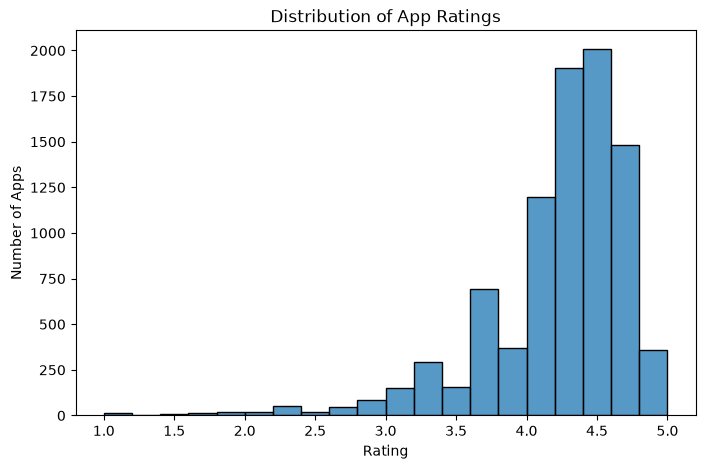

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(apps['Rating'].dropna(), bins=20)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

In [29]:
category_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

category_rating.head(10)

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
Name: Rating, dtype: float64

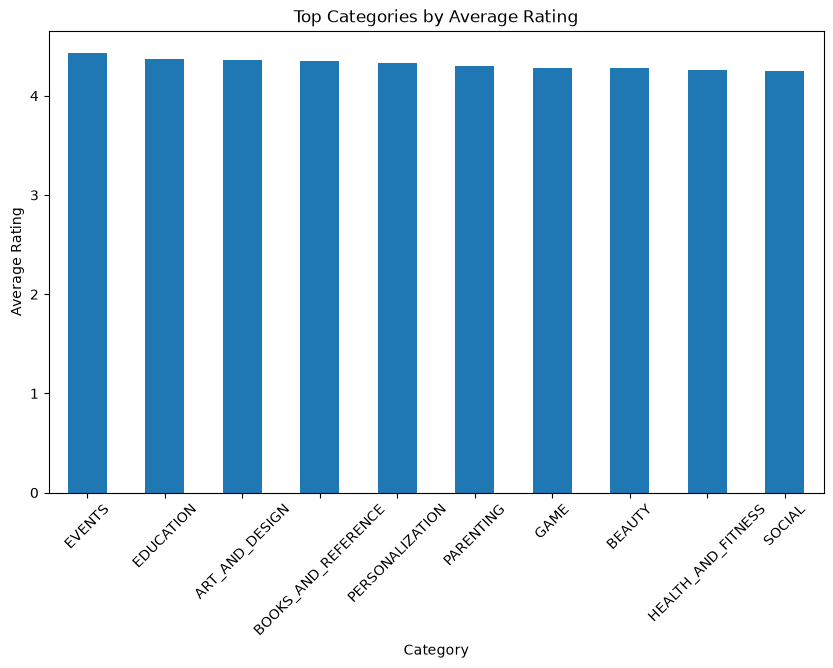

In [30]:
plt.figure(figsize=(10,6))

category_rating.head(10).plot(kind='bar')

plt.title('Top Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')

plt.xticks(rotation=45)
plt.show()

In [31]:
category_counts = apps['Category'].value_counts()

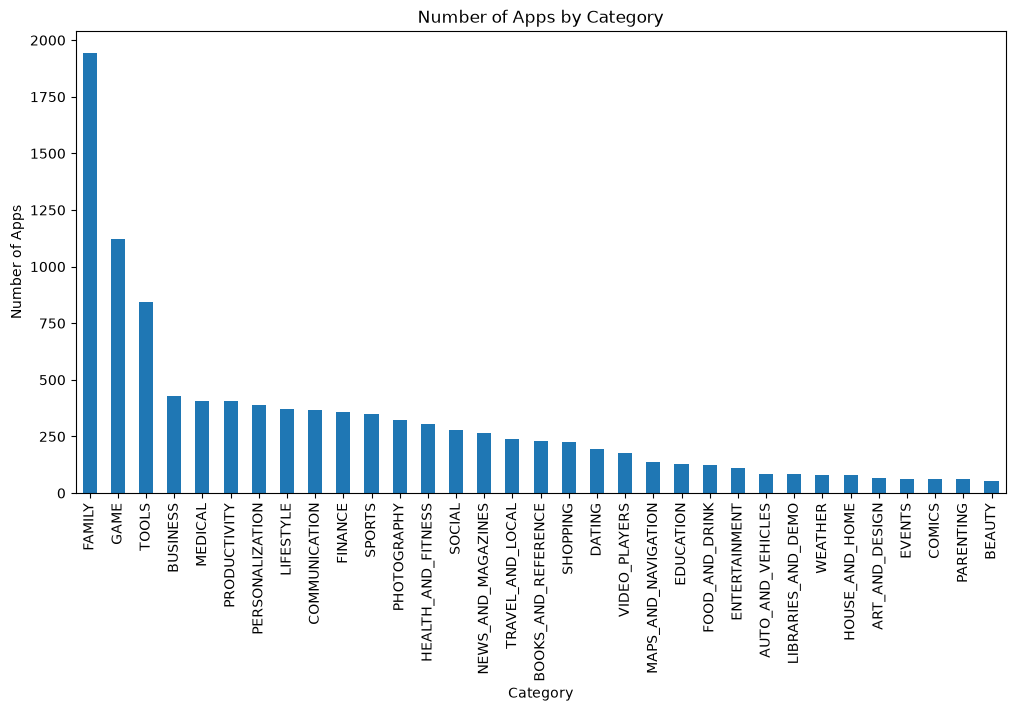

In [32]:
plt.figure(figsize=(12,6))

category_counts.plot(kind='bar')

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')

plt.xticks(rotation=90)
plt.show()

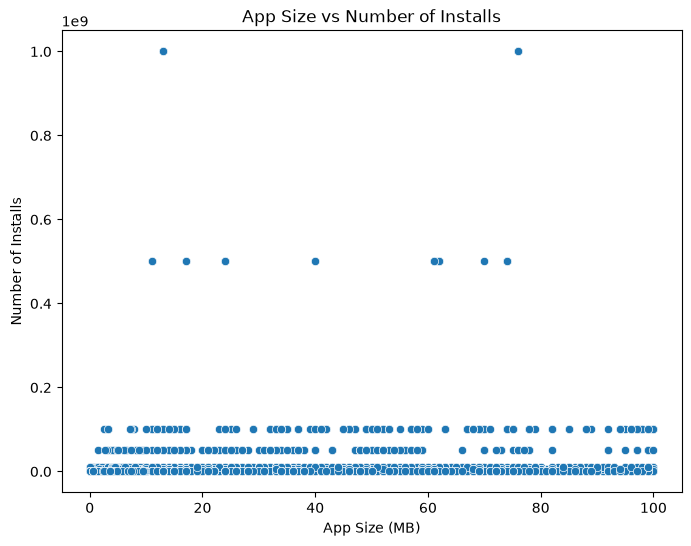

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=apps,
    x='Size_MB',
    y='Installs'
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')

plt.show()

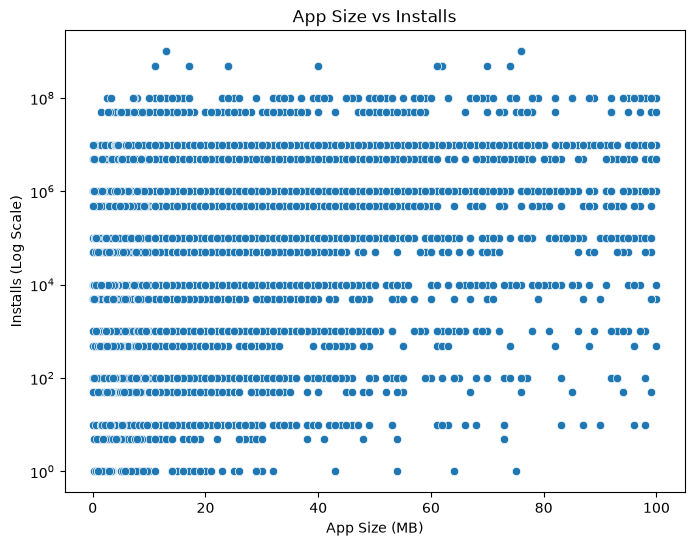

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=apps,
    x='Size_MB',
    y='Installs'
)

plt.yscale('log')

plt.title('App Size vs Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (Log Scale)')

plt.show()

In [35]:
apps[['Size_MB', 'Installs']].corr()

,Size_MB,Installs
Size_MB,1.000000,0.168872
Installs,0.168872,1.000000


In [36]:
apps['Type'].value_counts()

Type
Free    9591
Paid     765
Name: count, dtype: int64

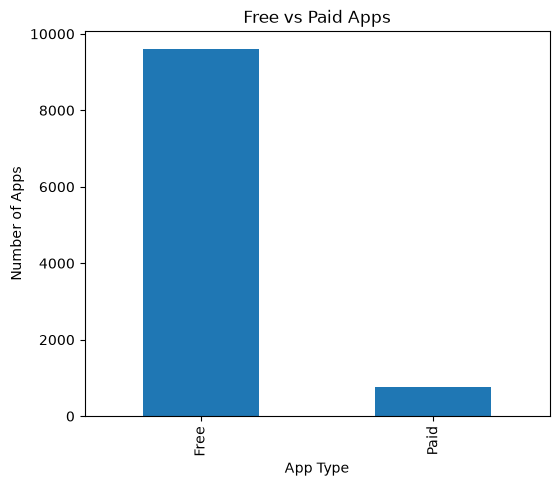

In [37]:
plt.figure(figsize=(6,5))

apps['Type'].value_counts().plot(
    kind='bar'
)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.show()

In [38]:
paid_apps = apps[apps['Type'] == 'Paid']

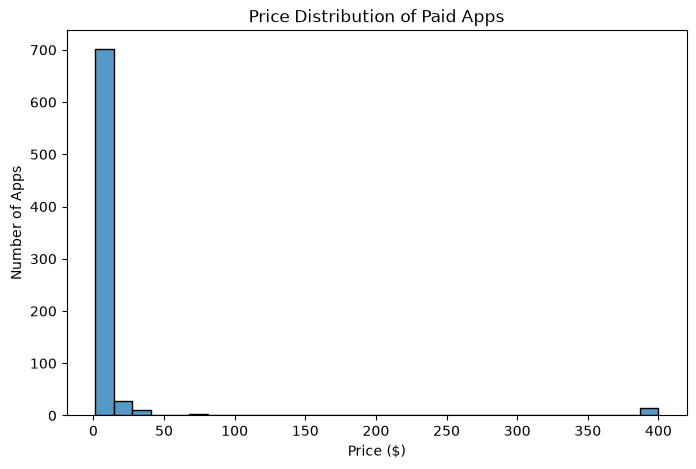

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    paid_apps['Price'],
    bins=30
)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

In [40]:
apps['Estimated_Revenue'] = apps['Price'] * apps['Installs']

In [41]:
category_revenue = apps.groupby(
    'Category'
)['Estimated_Revenue'].sum().sort_values(ascending=False)

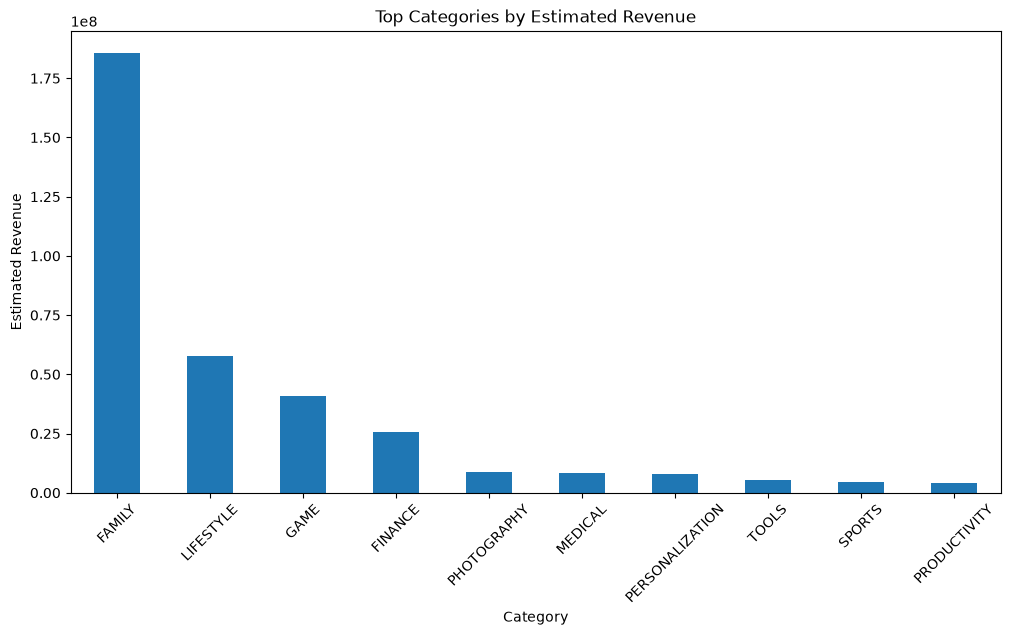

In [42]:
plt.figure(figsize=(12,6))

category_revenue.head(10).plot(kind='bar')

plt.title('Top Categories by Estimated Revenue')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue')

plt.xticks(rotation=45)
plt.show()

In [43]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [44]:
reviews['Sentiment'] = reviews['Translated_Review'].apply(get_sentiment)

In [45]:
reviews['Sentiment'].value_counts()

Sentiment
Positive    23997
Negative     8272
Neutral      5158
Name: count, dtype: int64

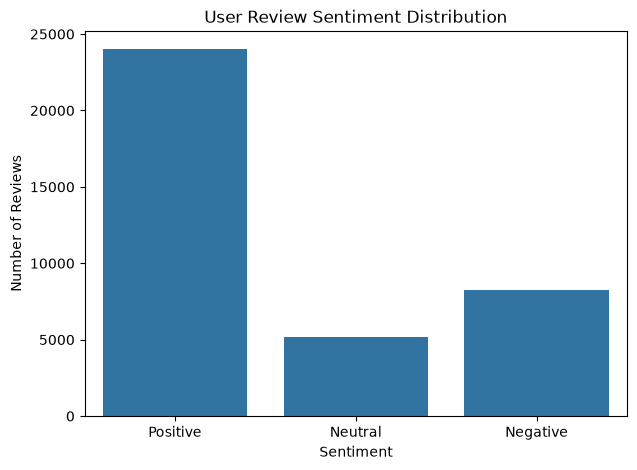

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x='Sentiment'
)

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [50]:
review_category = reviews.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)

In [51]:
review_category.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,HEALTH_AND_FITNESS


In [52]:
positive_category = review_category[
    review_category['Sentiment'] == 'Positive'
]['Category'].value_counts()

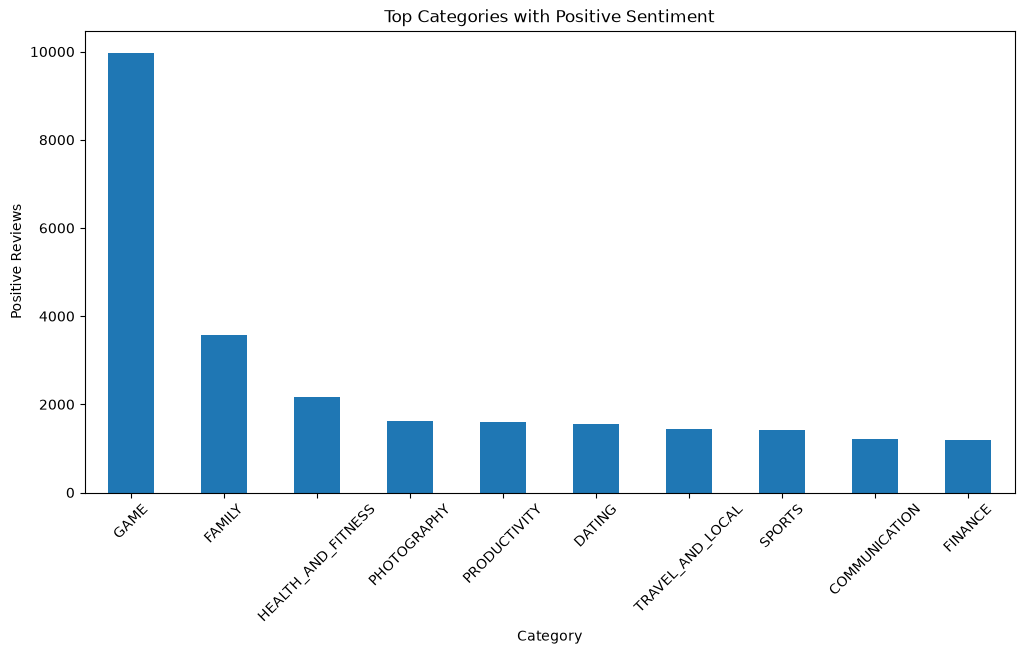

In [53]:
plt.figure(figsize=(12,6))

positive_category.head(10).plot(kind='bar')

plt.title('Top Categories with Positive Sentiment')
plt.xlabel('Category')
plt.ylabel('Positive Reviews')

plt.xticks(rotation=45)
plt.show()



In [54]:
negative_category = review_category[
    review_category['Sentiment'] == 'Negative'
]['Category'].value_counts()

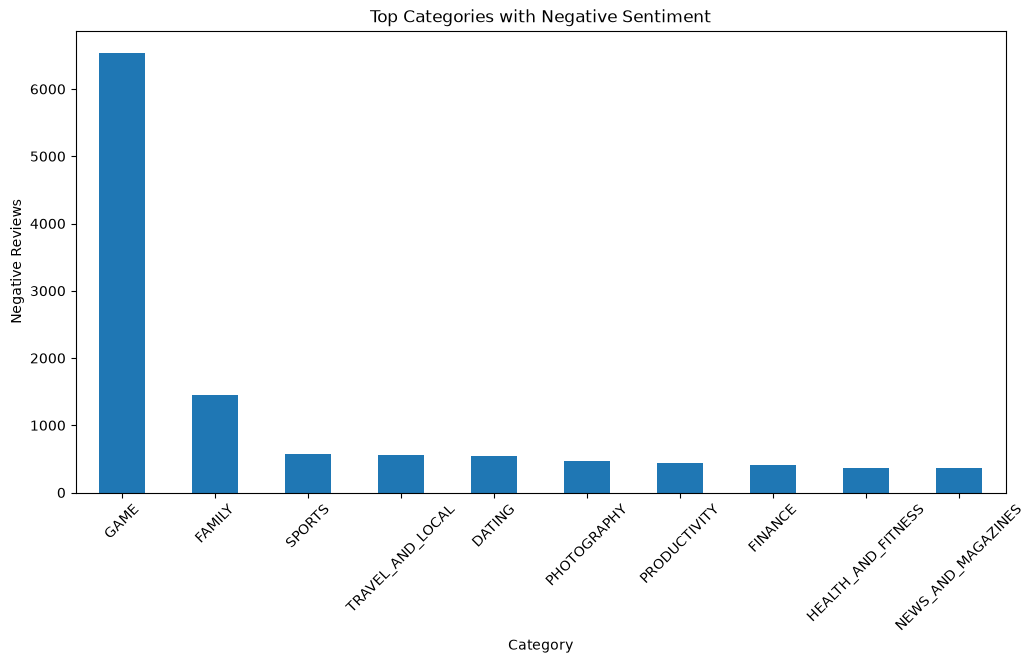

In [55]:
plt.figure(figsize=(12,6))

negative_category.head(10).plot(kind='bar')

plt.title('Top Categories with Negative Sentiment')
plt.xlabel('Category')
plt.ylabel('Negative Reviews')

plt.xticks(rotation=45)
plt.show()

In [66]:
fig = px.bar(
    category_counts.head(15),
    title='Top 15 App Categories'
)

fig.show()

## 5. Conclusion

The Google Play Store dataset was analyzed to understand app categories, ratings, installations, pricing, revenue, and user sentiment.

### Key Insights

1. **Category Distribution:**  
   Some app categories contain a large number of applications, indicating higher competition and market saturation.

2. **Ratings and User Sentiment:**  
   App ratings and review sentiment help identify how users respond to applications. Positive and negative reviews can provide useful information for improving app quality and user experience.

3. **Pricing and Revenue:**  
   The analysis of free and paid applications shows differences in pricing and estimated revenue across categories. This can help developers understand possible monetization opportunities.

### Final Conclusion

The analysis provides useful insights into the Google Play Store market. Developers can use category popularity, user ratings, installation trends, pricing patterns, and customer sentiment to understand the market and make data-driven decisions when planning a new application.